# **Comparative Deep Learning for Multiclass Skin Lesion Classification using the HAM10000 Dataset**

# [ResNet50 + Transformer,  EfficientNet-B3 + CBAM, EfficientNet-B0 + Transformer]

In [ ]:
!pip install -q torch torchvision scikit-learn pandas matplotlib seaborn pillow

In [ ]:
import os
import zipfile
import random
import copy
import time
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from torchvision import transforms
from torchvision.models import (
    resnet50,
    ResNet50_Weights,
    efficientnet_b0,
    EfficientNet_B0_Weights,
    efficientnet_b3,
    EfficientNet_B3_Weights
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Random seed:", SEED)

Random seed: 42


In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
ZIP_PATH = "/content/drive/MyDrive/dl_skin cancer_dataset.zip"

EXTRACT_PATH = "/content/ham10000"

In [ ]:
# EXTRACT DATASET
if not os.path.exists(EXTRACT_PATH):

    print("Extracting dataset...")

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_file:
        zip_file.extractall(EXTRACT_PATH)

    print("Dataset extraction completed.")

else:

    print("Dataset is already extracted.")

Extracting dataset...
Dataset extraction completed.


In [ ]:
# LOAD METADATA
metadata_path = None

for root, folders, files in os.walk(EXTRACT_PATH):

    if "HAM10000_metadata.csv" in files:

        metadata_path = os.path.join(
            root,
            "HAM10000_metadata.csv"
        )

        break

print("Metadata file:")
print(metadata_path)

Metadata file:
/content/ham10000/dl_skin cancer_dataset/HAM10000_metadata.csv


In [ ]:
# FIND ALL IMAGES
df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst five rows:")
display(df.head())

Dataset shape: (10015, 7)

Columns:
['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization']

First five rows:


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
# CONNECT IMAGES TO METADATA
image_paths = {}

for root, folders, files in os.walk(EXTRACT_PATH):

    for file in files:

        if file.lower().endswith(".jpg"):

            image_id = os.path.splitext(file)[0]

            image_paths[image_id] = os.path.join(
                root,
                file
            )

print("Number of JPG images found:", len(image_paths))

Number of JPG images found: 10015


In [ ]:
df["image_path"] = df["image_id"].map(image_paths)

missing = df["image_path"].isna().sum()

print("Missing images:", missing)

Missing images: 0


In [ ]:
df = df.dropna(
    subset=["image_path"]
).reset_index(drop=True)

print("Usable images:", len(df))

Usable images: 10015


In [ ]:
# DEFINE 7 CLASSES
class_names = [
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc"
]

class_to_index = {
    name: i
    for i, name in enumerate(class_names)
}

index_to_class = {
    i: name
    for name, i in class_to_index.items()
}

df["label"] = df["dx"].map(class_to_index)

print(df["label"].value_counts().sort_index())

label
0     327
1     514
2    1099
3     115
4    1113
5    6705
6     142
Name: count, dtype: int64


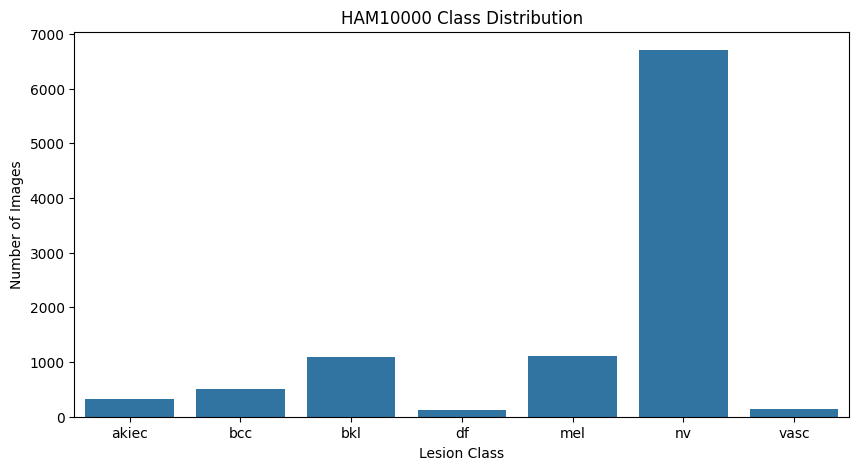

In [ ]:
# CLASS DISTRIBUTION
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="dx",
    order=class_names
)

plt.title("HAM10000 Class Distribution")
plt.xlabel("Lesion Class")
plt.ylabel("Number of Images")

plt.show()

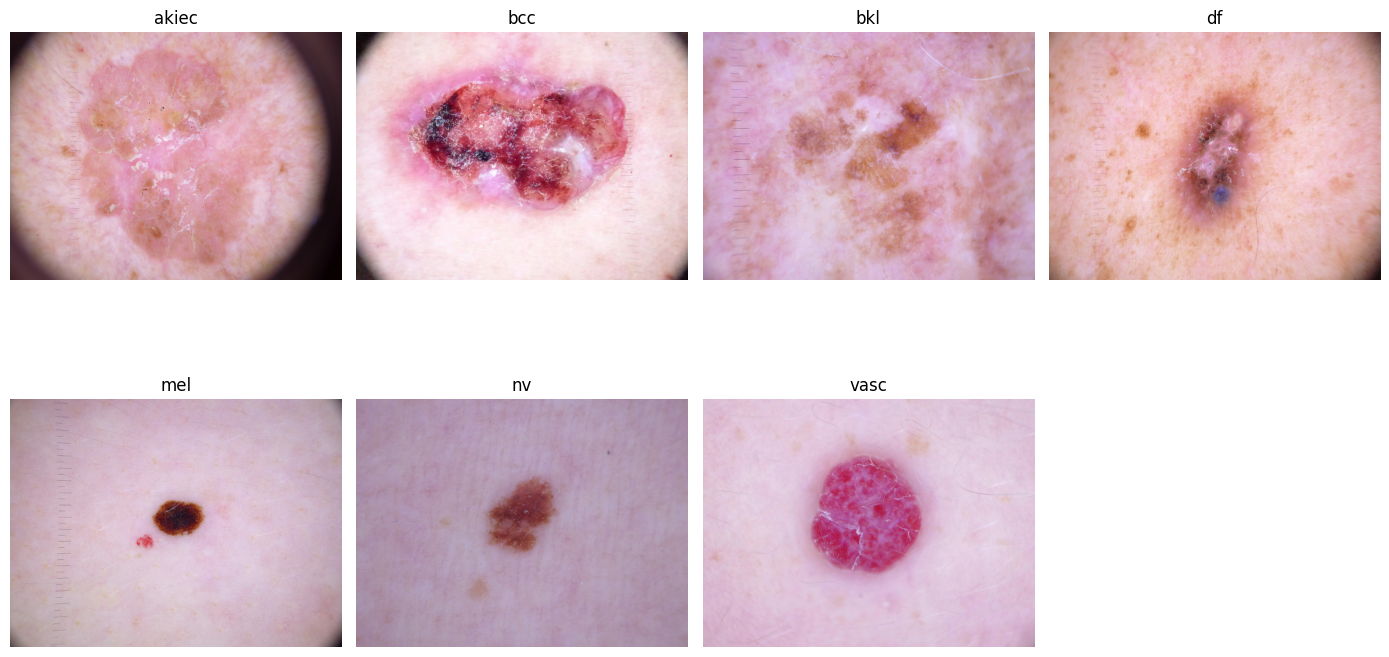

In [ ]:
# SAMPLE IMAGES
plt.figure(figsize=(14, 8))

for i, class_name in enumerate(class_names):

    sample = df[
        df["dx"] == class_name
    ].iloc[0]

    image = Image.open(
        sample["image_path"]
    ).convert("RGB")

    plt.subplot(2, 4, i + 1)

    plt.imshow(image)

    plt.title(class_name)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TRAIN-VALIDATION-TEST SPLIT
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=SEED
)

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))

Training images: 7010
Validation images: 1502
Testing images: 1503


In [ ]:
# IMAGE PREPROCESSING
IMAGE_SIZE = 224

IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406
]

IMAGENET_STD = [
    0.229,
    0.224,
    0.225
]

In [ ]:
# TRAINING TRANSFORMATION
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        20
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

In [ ]:
# VALIDATION-TEST TRANSFROMATION
test_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        IMAGENET_MEAN,
        IMAGENET_STD
    )
])

In [ ]:
# DATASET CLASS
class SkinLesionDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.dataframe = (
            dataframe
            .reset_index(drop=True)
        )

        self.transform = transform

    def __len__(self):

        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image = Image.open(
            row["image_path"]
        ).convert("RGB")

        label = int(row["label"])

        if self.transform:

            image = self.transform(image)

        return image, label

In [ ]:
# CREATE DATASETS
train_dataset = SkinLesionDataset(
    train_df,
    train_transform
)

val_dataset = SkinLesionDataset(
    val_df,
    test_transform
)

test_dataset = SkinLesionDataset(
    test_df,
    test_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 7010
Validation: 1502
Test: 1503


In [ ]:
# DATALOADERS
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


In [ ]:
# CLASS WEIGHTS
class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
)

print("Class counts:")
print(class_counts)

Class counts:
label
0     229
1     360
2     769
3      81
4     779
5    4693
6      99
Name: count, dtype: int64


In [ ]:
# CALCULATE WEIGHTS
class_weights = (
    len(train_df)
    /
    (
        len(class_names)
        * class_counts.values
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass weights:")

for i, weight in enumerate(class_weights):

    print(
        class_names[i],
        ":",
        round(weight.item(), 4)
    )


Class weights:
akiec : 4.3731
bcc : 2.7817
bkl : 1.3022
df : 12.3633
mel : 1.2855
nv : 0.2134
vasc : 10.1154


In [ ]:
# COMMON TRAINING FUNCTION
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer
):

    model.train()

    total_loss = 0

    all_predictions = []
    all_labels = []

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = outputs.argmax(
            dim=1
        )

        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )

        all_labels.extend(
            labels.detach()
            .cpu()
            .numpy()
        )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        total_loss / len(loader),
        accuracy,
        macro_f1
    )

In [ ]:
# VALIDATION FUNCTION
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    total_loss = 0

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            total_loss += loss.item()

            predictions = outputs.argmax(
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.cpu().numpy()
            )

    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )

    return (
        total_loss / len(loader),
        accuracy,
        macro_f1
    )

In [ ]:
# GENERIC MODEL TRAINING FUNCTION
def train_model(
    model,
    model_name,
    epochs=15,
    learning_rate=1e-4
):

    print("\n")
    print("=" * 70)
    print("TRAINING:", model_name)
    print("=" * 70)

    model = model.to(device)

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.05
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2
    )

    best_f1 = -1

    best_state = None

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": []
    }

    start_time = time.time()

    for epoch in range(epochs):

        train_loss, train_acc, train_f1 = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc, val_f1 = evaluate(
            model,
            val_loader,
            criterion
        )

        scheduler.step(val_f1)

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["train_acc"].append(
            train_acc
        )

        history["val_acc"].append(
            val_acc
        )

        history["train_f1"].append(
            train_f1
        )

        history["val_f1"].append(
            val_f1
        )

        print(
            f"Epoch {epoch + 1:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Train F1: {train_f1:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f} | "
            f"Val F1: {val_f1:.4f}"
        )

        if val_f1 > best_f1:

            best_f1 = val_f1

            best_state = copy.deepcopy(
                model.state_dict()
            )

    training_time = (
        time.time() - start_time
    )

    model.load_state_dict(
        best_state
    )

    print(
        "\nBest validation Macro-F1:",
        round(best_f1, 4)
    )

    print(
        "Training time:",
        round(training_time / 60, 2),
        "minutes"
    )

    return (
        model,
        history,
        training_time
    )

## MODEL 1 : ResNet50 + Transformer

In [ ]:
class ResNetTransformer(nn.Module):

    def __init__(
        self,
        num_classes=7,
        d_model=256,
        num_heads=8,
        num_layers=2,
        dropout=0.3
    ):

        super().__init__()

        weights = (
            ResNet50_Weights.DEFAULT
        )

        backbone = resnet50(
            weights=weights
        )

        self.cnn = nn.Sequential(
            *list(
                backbone.children()
            )[:-2]
        )

        self.projection = nn.Conv2d(
            2048,
            d_model,
            kernel_size=1
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=num_heads,
                dim_feedforward=512,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )

        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )

        self.classifier = nn.Sequential(

            nn.LayerNorm(d_model),

            nn.Dropout(dropout),

            nn.Linear(
                d_model,
                num_classes
            )
        )

    def forward(self, x):

        x = self.cnn(x)
        x = self.projection(x)
        batch_size = x.size(0)
        x = x.flatten(
            2
        )

        x = x.transpose(
            1,
            2
        )

        x = self.transformer(x)
        x = x.mean(
            dim=1
        )

        x = self.classifier(x)
        return x

In [ ]:
# BUILD MODEL
model1 = ResNetTransformer(
    num_classes=7
)

print(
    "ResNet50 + Transformer created."
)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


ResNet50 + Transformer created.


/tmp/ipykernel_999/3769428814.py:46: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


In [ ]:
# TRAIN MODEL
model1, history1, time1 = train_model(
    model1,
    "ResNet50 + Transformer",
    epochs=15,
    learning_rate=1e-4
)



TRAINING: ResNet50 + Transformer
Epoch 01/15 | Train Loss: 1.9542 | Train Acc: 0.4068 | Train F1: 0.3026 | Val Loss: 1.6207 | Val Acc: 0.5553 | Val F1: 0.4317
Epoch 02/15 | Train Loss: 1.5951 | Train Acc: 0.5826 | Train F1: 0.4616 | Val Loss: 1.4602 | Val Acc: 0.7130 | Val F1: 0.6306
Epoch 03/15 | Train Loss: 1.4718 | Train Acc: 0.6571 | Train F1: 0.5338 | Val Loss: 1.3972 | Val Acc: 0.7437 | Val F1: 0.6069
Epoch 04/15 | Train Loss: 1.3787 | Train Acc: 0.7076 | Train F1: 0.5867 | Val Loss: 1.3311 | Val Acc: 0.7823 | Val F1: 0.6642
Epoch 05/15 | Train Loss: 1.2956 | Train Acc: 0.7468 | Train F1: 0.6409 | Val Loss: 1.3317 | Val Acc: 0.7703 | Val F1: 0.6719
Epoch 06/15 | Train Loss: 1.2563 | Train Acc: 0.7559 | Train F1: 0.6530 | Val Loss: 1.3055 | Val Acc: 0.7617 | Val F1: 0.6226
Epoch 07/15 | Train Loss: 1.2056 | Train Acc: 0.7840 | Train F1: 0.6955 | Val Loss: 1.2886 | Val Acc: 0.8096 | Val F1: 0.7256
Epoch 08/15 | Train Loss: 1.1606 | Train Acc: 0.8021 | Train F1: 0.7239 | Val Loss:

## MODEL 2: EfficientNet-B3 + CBAM

In [ ]:
# CBAM
class ChannelAttention(nn.Module):

    def __init__(
        self,
        channels,
        reduction=16
    ):

        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(

            nn.Conv2d(
                channels,
                channels // reduction,
                kernel_size=1,
                bias=False
            ),

            nn.ReLU(),

            nn.Conv2d(
                channels // reduction,
                channels,
                kernel_size=1,
                bias=False
            )
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg_attention = self.mlp(
            self.avg_pool(x)
        )

        max_attention = self.mlp(
            self.max_pool(x)
        )

        attention = (
            avg_attention
            +
            max_attention
        )

        return x * self.sigmoid(
            attention
        )

In [ ]:
# SPATIAL ATTENTION
class SpatialAttention(nn.Module):

    def __init__(
        self,
        kernel_size=7
    ):

        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=kernel_size,
            padding=kernel_size // 2,
            bias=False
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):

        avg = torch.mean(
            x,
            dim=1,
            keepdim=True
        )

        maximum = torch.max(
            x,
            dim=1,
            keepdim=True
        )[0]

        combined = torch.cat(
            [avg, maximum],
            dim=1
        )

        attention = self.conv(
            combined
        )

        return x * self.sigmoid(
            attention
        )

In [ ]:
# COMPLETE CBAM
class CBAM(nn.Module):

    def __init__(
        self,
        channels
    ):

        super().__init__()

        self.channel_attention = (
            ChannelAttention(
                channels
            )
        )

        self.spatial_attention = (
            SpatialAttention()
        )

    def forward(self, x):

        x = self.channel_attention(x)
        x = self.spatial_attention(x)

        return x

In [ ]:
# EFFICIENTNET-B3 + CBAM
class EfficientNetCBAM(nn.Module):

    def __init__(
        self,
        num_classes=7,
        dropout=0.4
    ):

        super().__init__()

        weights = (
            EfficientNet_B3_Weights.DEFAULT
        )

        backbone = efficientnet_b3(
            weights=weights
        )

        self.features = (
            backbone.features
        )

        self.cbam = CBAM(
            channels=1536
        )

        self.pool = (
            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Dropout(dropout),

            nn.Linear(
                1536,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)
        x = self.cbam(x)
        x = self.pool(x)
        x = self.classifier(x)

        return x

In [ ]:
# BUILD MODEL
model2 = EfficientNetCBAM(
    num_classes=7
)

print(
    "EfficientNet-B3 + CBAM created."
)

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 104MB/s]


EfficientNet-B3 + CBAM created.


In [ ]:
# TRAIN MODEL
model2, history2, time2 = train_model(
    model2,
    "EfficientNet-B3 + CBAM",
    epochs=15,
    learning_rate=1e-4
)



TRAINING: EfficientNet-B3 + CBAM
Epoch 01/15 | Train Loss: 2.0960 | Train Acc: 0.4116 | Train F1: 0.2760 | Val Loss: 1.6505 | Val Acc: 0.5699 | Val F1: 0.4503
Epoch 02/15 | Train Loss: 1.5768 | Train Acc: 0.6200 | Train F1: 0.4843 | Val Loss: 1.4887 | Val Acc: 0.6791 | Val F1: 0.5512
Epoch 03/15 | Train Loss: 1.4566 | Train Acc: 0.6806 | Train F1: 0.5487 | Val Loss: 1.4213 | Val Acc: 0.7450 | Val F1: 0.6106
Epoch 04/15 | Train Loss: 1.3645 | Train Acc: 0.7100 | Train F1: 0.6009 | Val Loss: 1.3554 | Val Acc: 0.7457 | Val F1: 0.6267
Epoch 05/15 | Train Loss: 1.3132 | Train Acc: 0.7284 | Train F1: 0.6308 | Val Loss: 1.3324 | Val Acc: 0.7810 | Val F1: 0.6751
Epoch 06/15 | Train Loss: 1.2471 | Train Acc: 0.7702 | Train F1: 0.6830 | Val Loss: 1.2804 | Val Acc: 0.7943 | Val F1: 0.6799
Epoch 07/15 | Train Loss: 1.2116 | Train Acc: 0.7874 | Train F1: 0.7080 | Val Loss: 1.2891 | Val Acc: 0.7803 | Val F1: 0.7285
Epoch 08/15 | Train Loss: 1.1434 | Train Acc: 0.8020 | Train F1: 0.7341 | Val Loss:

## MODEL 3 : EfficientNet-B0 + Transformer

In [ ]:
# POSITIONAL ENCODING
class PositionalEncoding(nn.Module):

    def __init__(
        self,
        d_model,
        max_len=196
    ):

        super().__init__()

        position = torch.arange(
            max_len
        ).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(
                0,
                d_model,
                2
            )
            *
            (
                -math.log(10000.0)
                / d_model
            )
        )

        pe = torch.zeros(
            max_len,
            d_model
        )

        pe[:, 0::2] = torch.sin(
            position * div_term
        )

        pe[:, 1::2] = torch.cos(
            position * div_term
        )

        pe = pe.unsqueeze(0)
        self.register_buffer(
            "pe",
            pe
        )

    def forward(self, x):

        return (
            x
            +
            self.pe[
                :, :x.size(1)
            ]
        )

In [ ]:
# EFFICIENTNET + TRANSFORMER
class EfficientNetTransformer(nn.Module):

    def __init__(
        self,
        num_classes=7,
        d_model=256,
        num_heads=8,
        num_layers=2,
        dropout=0.3
    ):

        super().__init__()

        weights = (
            EfficientNet_B0_Weights.DEFAULT
        )

        backbone = efficientnet_b0(
            weights=weights
        )

        self.cnn = (
            backbone.features
        )

        self.projection = nn.Conv2d(
            1280,
            d_model,
            kernel_size=1
        )

        self.position = (
            PositionalEncoding(
                d_model
            )
        )

        encoder_layer = (
            nn.TransformerEncoderLayer(
                d_model=d_model,
                nhead=num_heads,
                dim_feedforward=512,
                dropout=dropout,
                batch_first=True,
                norm_first=True
            )
        )

        self.transformer = (
            nn.TransformerEncoder(
                encoder_layer,
                num_layers=num_layers
            )
        )

        self.classifier = nn.Sequential(

            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(
                d_model,
                num_classes
            )
        )

    def forward(self, x):
        x = self.cnn(x)
        x = self.projection(x)

        x = x.flatten(
            2
        )
        x = x.transpose(
            1,
            2
        )

        x = self.position(x)
        x = self.transformer(x)

        x = x.mean(
            dim=1
        )

        x = self.classifier(x)
        return x

In [ ]:
# BUILD MODEL
model3 = EfficientNetTransformer(
    num_classes=7
)

print(
    "EfficientNet-B0 + Transformer created."
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 178MB/s]


EfficientNet-B0 + Transformer created.


/tmp/ipykernel_999/2223174406.py:51: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  nn.TransformerEncoder(


In [ ]:
# TRAIN MODEL
model3, history3, time3 = train_model(
    model3,
    "EfficientNet-B0 + Transformer",
    epochs=15,
    learning_rate=1e-4
)



TRAINING: EfficientNet-B0 + Transformer
Epoch 01/15 | Train Loss: 2.0047 | Train Acc: 0.3700 | Train F1: 0.2821 | Val Loss: 1.5659 | Val Acc: 0.5146 | Val F1: 0.4347
Epoch 02/15 | Train Loss: 1.6253 | Train Acc: 0.5716 | Train F1: 0.4423 | Val Loss: 1.4390 | Val Acc: 0.6771 | Val F1: 0.5371
Epoch 03/15 | Train Loss: 1.4907 | Train Acc: 0.6485 | Train F1: 0.5174 | Val Loss: 1.3466 | Val Acc: 0.7184 | Val F1: 0.5893
Epoch 04/15 | Train Loss: 1.3776 | Train Acc: 0.6942 | Train F1: 0.5780 | Val Loss: 1.3615 | Val Acc: 0.7270 | Val F1: 0.6095
Epoch 05/15 | Train Loss: 1.3452 | Train Acc: 0.7175 | Train F1: 0.6031 | Val Loss: 1.3149 | Val Acc: 0.6951 | Val F1: 0.5837
Epoch 06/15 | Train Loss: 1.2547 | Train Acc: 0.7288 | Train F1: 0.6362 | Val Loss: 1.3004 | Val Acc: 0.8116 | Val F1: 0.7272
Epoch 07/15 | Train Loss: 1.2373 | Train Acc: 0.7675 | Train F1: 0.6789 | Val Loss: 1.3064 | Val Acc: 0.7790 | Val F1: 0.6711
Epoch 08/15 | Train Loss: 1.2020 | Train Acc: 0.7842 | Train F1: 0.7055 | Va

In [ ]:
# TEST PREDICTIONS
def get_predictions(
    model,
    loader
):

    model.eval()

    all_predictions = []
    all_labels = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            outputs = model(images)

            predictions = outputs.argmax(
                dim=1
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_labels.extend(
                labels.numpy()
            )

    return (
        np.array(all_labels),
        np.array(all_predictions)
    )

In [ ]:
# PREDICT WITH ALL MODELS
y_true1, y_pred1 = get_predictions(
    model1,
    test_loader
)

y_true2, y_pred2 = get_predictions(
    model2,
    test_loader
)

y_true3, y_pred3 = get_predictions(
    model3,
    test_loader
)

print("Predictions generated for all models.")

Predictions generated for all models.


In [ ]:
# EVALUATION FUNCTION
def calculate_metrics(
    y_true,
    y_pred
):

    return {

        "Accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "Macro Precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro Recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Macro F1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        ),

        "Balanced Accuracy": balanced_accuracy_score(
            y_true,
            y_pred
        )
    }

In [ ]:
# FINAL COMPARISON TABLE
results = {

    "ResNet50 + Transformer":
        calculate_metrics(
            y_true1,
            y_pred1
        ),

    "EfficientNet-B3 + CBAM":
        calculate_metrics(
            y_true2,
            y_pred2
        ),

    "EfficientNet-B0 + Transformer":
        calculate_metrics(
            y_true3,
            y_pred3
        )
}

results_df = pd.DataFrame(
    results
).T

results_df

,Accuracy,Macro Precision,Macro Recall,Macro F1,Balanced Accuracy
ResNet50 + Transformer,0.853626,0.702542,0.820068,0.753220,0.820068
EfficientNet-B3 + CBAM,0.840319,0.743693,0.792328,0.756084,0.792328
EfficientNet-B0 + Transformer,0.857618,0.734608,0.807808,0.765837,0.807808


In [ ]:
# SORT BY MACRO-F1
results_sorted = results_df.sort_values(
    by="Macro F1",
    ascending=False
)

display(results_sorted)

,Accuracy,Macro Precision,Macro Recall,Macro F1,Balanced Accuracy
EfficientNet-B0 + Transformer,0.857618,0.734608,0.807808,0.765837,0.807808
EfficientNet-B3 + CBAM,0.840319,0.743693,0.792328,0.756084,0.792328
ResNet50 + Transformer,0.853626,0.702542,0.820068,0.753220,0.820068


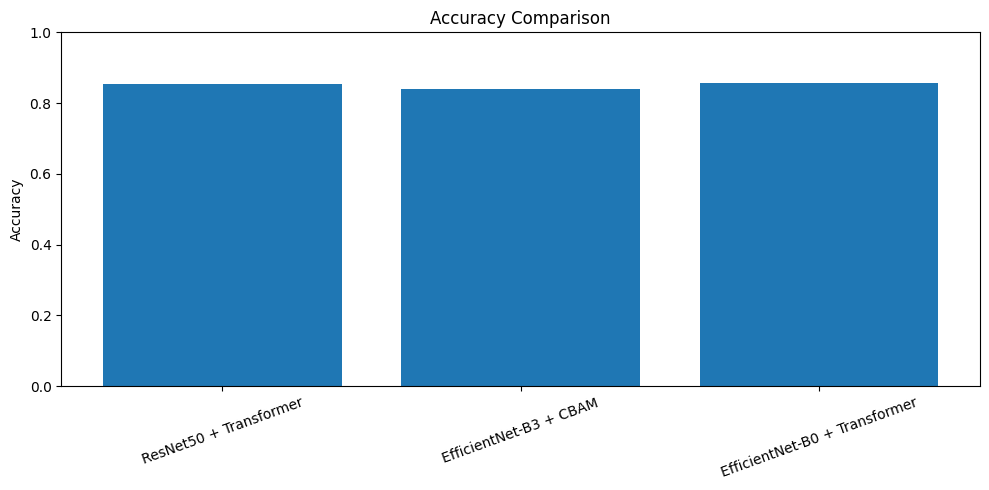

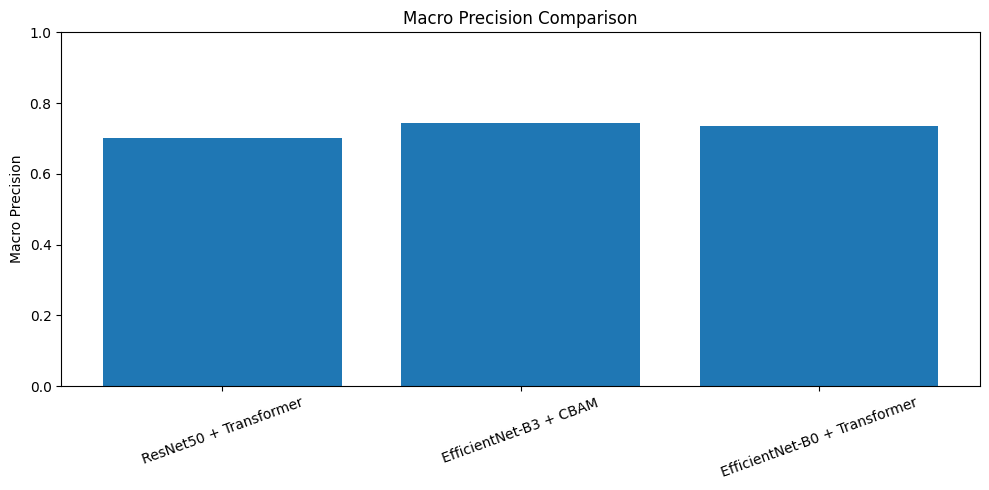

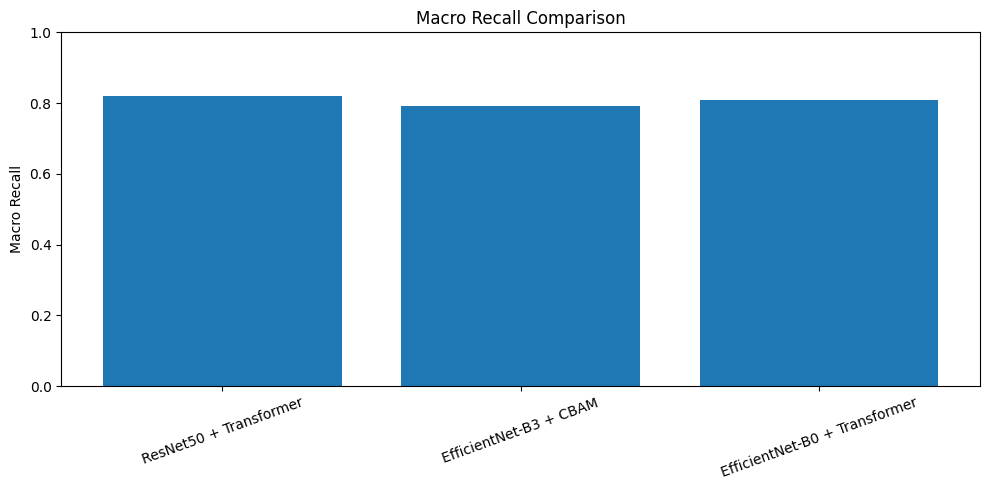

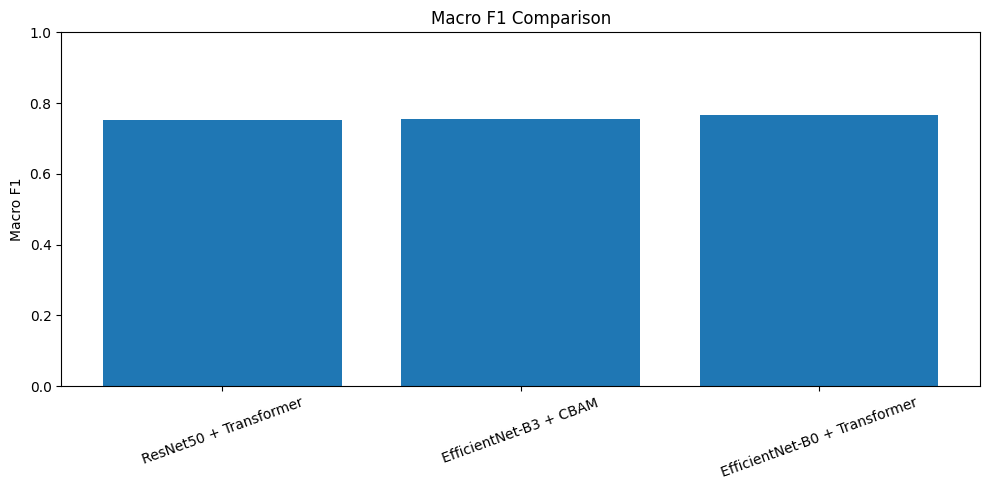

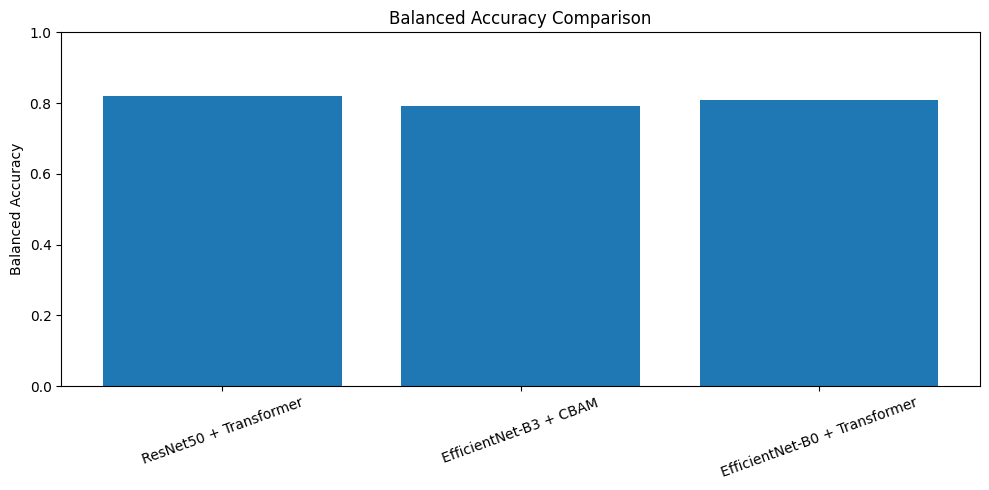

In [ ]:
# VISUAL COMPARISON
metrics_to_plot = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Balanced Accuracy"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(10, 5))

    plt.bar(
        results_df.index,
        results_df[metric]
    )

    plt.title(
        metric + " Comparison"
    )

    plt.ylabel(metric)

    plt.xticks(
        rotation=20
    )

    plt.ylim(0, 1)

    plt.tight_layout()

    plt.show()

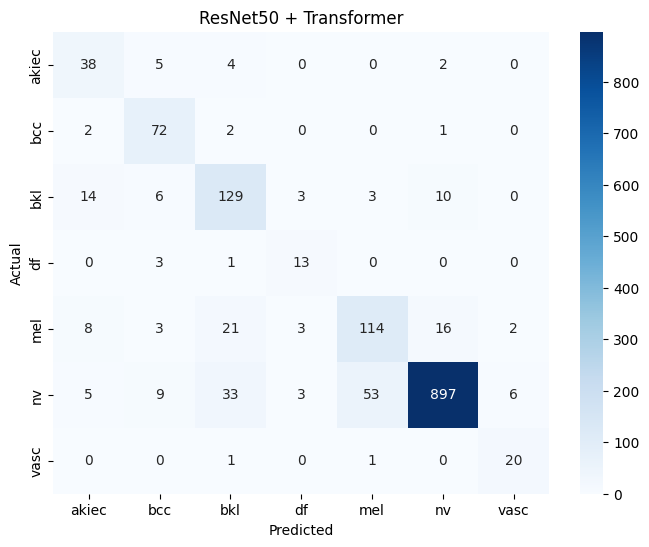

In [ ]:
# CONFUSION MATRICES

# MODEL 1
cm1 = confusion_matrix(
    y_true1,
    y_pred1
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm1,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "ResNet50 + Transformer"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

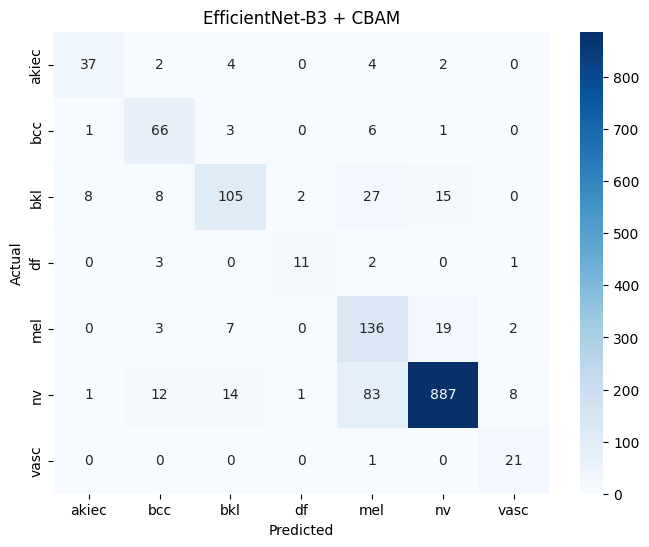

In [ ]:
# MODEL 2
cm2 = confusion_matrix(
    y_true2,
    y_pred2
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "EfficientNet-B3 + CBAM"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

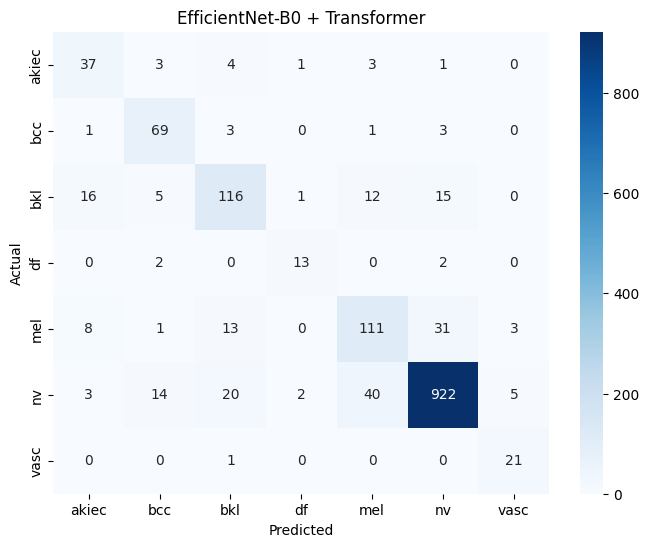

In [ ]:
# MODEL 3
cm3 = confusion_matrix(
    y_true3,
    y_pred3
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm3,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "EfficientNet-B0 + Transformer"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# CLASSIFICATION REPORTS
print(
    "=" * 70
)

print(
    "MODEL 1: RESNET50 + TRANSFORMER"
)

print(
    "=" * 70
)

print(
    classification_report(
        y_true1,
        y_pred1,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

MODEL 1: RESNET50 + TRANSFORMER
              precision    recall  f1-score   support

       akiec     0.5672    0.7755    0.6552        49
         bcc     0.7347    0.9351    0.8229        77
         bkl     0.6754    0.7818    0.7247       165
          df     0.5909    0.7647    0.6667        17
         mel     0.6667    0.6826    0.6746       167
          nv     0.9687    0.8917    0.9286      1006
        vasc     0.7143    0.9091    0.8000        22

    accuracy                         0.8536      1503
   macro avg     0.7025    0.8201    0.7532      1503
weighted avg     0.8699    0.8536    0.8588      1503



In [ ]:
print(
    "=" * 70
)

print(
    "MODEL 2: EFFICIENTNET-B3 + CBAM"
)

print(
    "=" * 70
)

print(
    classification_report(
        y_true2,
        y_pred2,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

MODEL 2: EFFICIENTNET-B3 + CBAM
              precision    recall  f1-score   support

       akiec     0.7872    0.7551    0.7708        49
         bcc     0.7021    0.8571    0.7719        77
         bkl     0.7895    0.6364    0.7047       165
          df     0.7857    0.6471    0.7097        17
         mel     0.5251    0.8144    0.6385       167
          nv     0.9600    0.8817    0.9192      1006
        vasc     0.6562    0.9545    0.7778        22

    accuracy                         0.8403      1503
   macro avg     0.7437    0.7923    0.7561      1503
weighted avg     0.8677    0.8403    0.8476      1503



In [ ]:
print(
    "=" * 70
)

print(
    "MODEL 3: EFFICIENTNET-B0 + TRANSFORMER"
)

print(
    "=" * 70
)

print(
    classification_report(
        y_true3,
        y_pred3,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

MODEL 3: EFFICIENTNET-B0 + TRANSFORMER
              precision    recall  f1-score   support

       akiec     0.5692    0.7551    0.6491        49
         bcc     0.7340    0.8961    0.8070        77
         bkl     0.7389    0.7030    0.7205       165
          df     0.7647    0.7647    0.7647        17
         mel     0.6647    0.6647    0.6647       167
          nv     0.9466    0.9165    0.9313      1006
        vasc     0.7241    0.9545    0.8235        22

    accuracy                         0.8576      1503
   macro avg     0.7346    0.8078    0.7658      1503
weighted avg     0.8640    0.8576    0.8595      1503



In [ ]:
# TRAINING CURVES
histories = {
    "ResNet50 + Transformer": history1,
    "EfficientNet-B3 + CBAM": history2,
    "EfficientNet-B0 + Transformer": history3
}

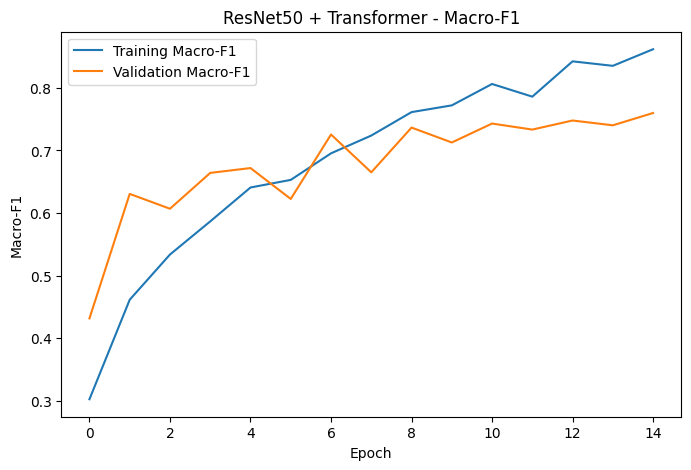

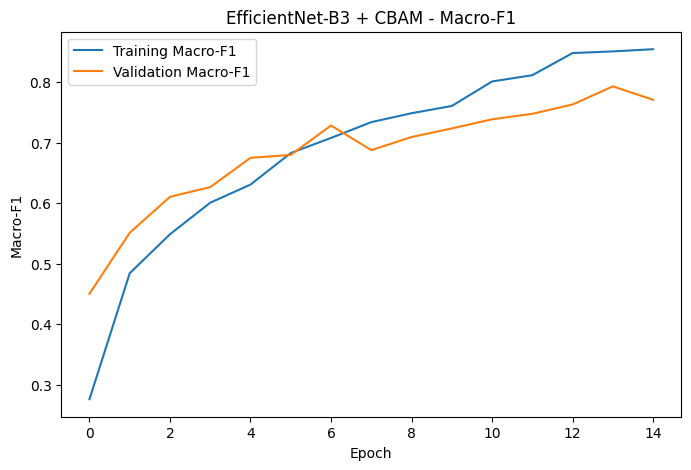

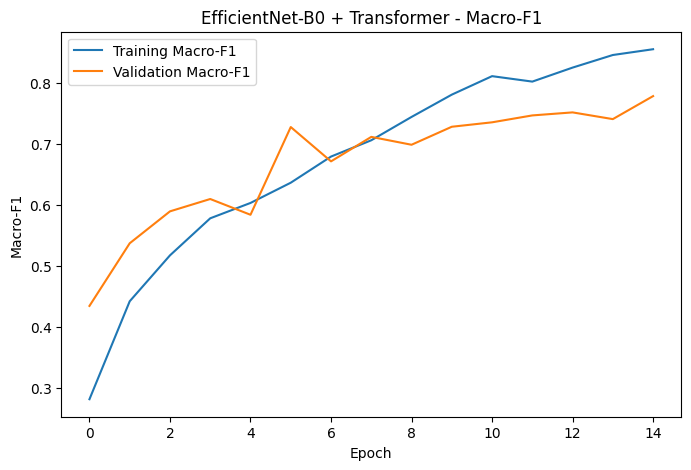

In [ ]:
# VALIDATION MACRO-F1
for name, history in histories.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_f1"],
        label="Training Macro-F1"
    )

    plt.plot(
        history["val_f1"],
        label="Validation Macro-F1"
    )

    plt.title(
        name + " - Macro-F1"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")

    plt.legend()

    plt.show()

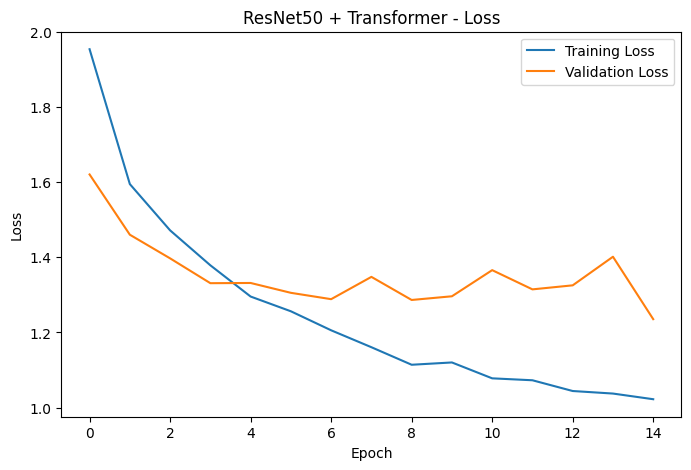

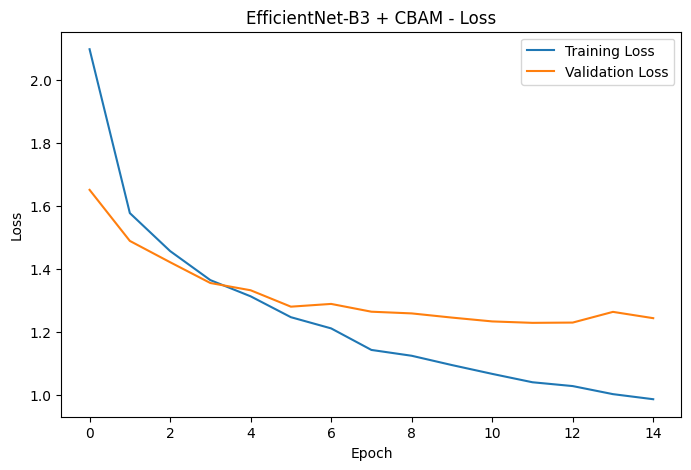

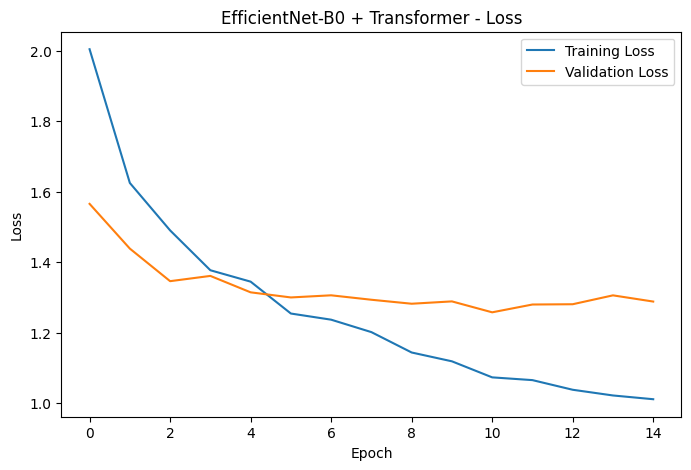

In [ ]:
# LOSS CURVES
for name, history in histories.items():

    plt.figure(figsize=(8, 5))

    plt.plot(
        history["train_loss"],
        label="Training Loss"
    )

    plt.plot(
        history["val_loss"],
        label="Validation Loss"
    )

    plt.title(
        name + " - Loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.legend()

    plt.show()

In [ ]:
# PARAMETER COUNT
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

parameter_results = pd.DataFrame({

    "Model": [
        "ResNet50 + Transformer",
        "EfficientNet-B3 + CBAM",
        "EfficientNet-B0 + Transformer"
    ],

    "Trainable Parameters": [
        count_parameters(model1),
        count_parameters(model2),
        count_parameters(model3)
    ],

    "Training Time (minutes)": [
        time1 / 60,
        time2 / 60,
        time3 / 60
    ]
})

parameter_results

,Model,Trainable Parameters,Training Time (minutes)
0,ResNet50 + Transformer,25089095,26.916185
1,EfficientNet-B3 + CBAM,11002001,26.575459
2,EfficientNet-B0 + Transformer,5392003,23.032777


In [ ]:
# SAVE MODELS
os.makedirs(
    "/content/drive/MyDrive/HAM10000_Models",
    exist_ok=True
)

In [ ]:
torch.save(
    model1.state_dict(),
    "/content/drive/MyDrive/HAM10000_Models/resnet50_transformer.pth"
)

torch.save(
    model2.state_dict(),
    "/content/drive/MyDrive/HAM10000_Models/efficientnet_b3_cbam.pth"
)

torch.save(
    model3.state_dict(),
    "/content/drive/MyDrive/HAM10000_Models/efficientnet_b0_transformer.pth"
)

print("All models saved.")

All models saved.


In [ ]:
# GRAD-CAM
class SimpleGradCAM:

    def __init__(
        self,
        model,
        target_layer
    ):

        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        target_layer.register_forward_hook(
            self.save_activation
        )

        target_layer.register_full_backward_hook(
            self.save_gradient
        )

    def save_activation(
        self,
        module,
        input,
        output
    ):

        self.activations = output

    def save_gradient(
        self,
        module,
        grad_input,
        grad_output
    ):

        self.gradients = grad_output[0]

    def generate(
        self,
        image
    ):

        self.model.eval()
        self.model.zero_grad()
        output = self.model(
            image
        )

        predicted_class = output.argmax(
            dim=1
        ).item()

        score = output[
            0,
            predicted_class
        ]

        score.backward()
        gradients = self.gradients
        activations = self.activations

        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        cam = (
            weights * activations
        ).sum(
            dim=1
        )

        cam = F.relu(cam)
        cam = F.interpolate(
            cam.unsqueeze(1),
            size=(
                IMAGE_SIZE,
                IMAGE_SIZE
            ),
            mode="bilinear",
            align_corners=False
        )

        cam = cam.squeeze()
        cam -= cam.min()
        cam /= (
            cam.max()
            +
            1e-8
        )

        return (
            cam.detach().cpu().numpy(),
            predicted_class
        )

In [ ]:
# GRAD-CAM TARGET LAYERS
gradcam1 = SimpleGradCAM(
    model1,
    model1.cnn[-1]
)

gradcam2 = SimpleGradCAM(
    model2,
    model2.features[-1]
)

gradcam3 = SimpleGradCAM(
    model3,
    model3.cnn[-1]
)

print("Grad-CAM objects created.")

Grad-CAM objects created.


In [ ]:
# SELECT A TEST IMAGE
sample_index = 2

image, true_label = test_dataset[
    sample_index
]

input_image = (
    image
    .unsqueeze(0)
    .to(device)
)

print(
    "True class:",
    class_names[true_label]
)

True class: bkl


In [ ]:
# GENERATE GRAD-CAM FOR ALL THREE
heatmap1, prediction1 = gradcam1.generate(
    input_image
)

heatmap2, prediction2 = gradcam2.generate(
    input_image
)

heatmap3, prediction3 = gradcam3.generate(
    input_image
)

print(
    "Model 1:",
    class_names[prediction1]
)

print(
    "Model 2:",
    class_names[prediction2]
)

print(
    "Model 3:",
    class_names[prediction3]
)

Model 1: bkl
Model 2: bkl
Model 3: bkl


In [ ]:
# RESTORE IMAGE FOR DISPLAY
display_image = (
    image
    .permute(1, 2, 0)
    .numpy()
)

display_image = (
    display_image
    * np.array(IMAGENET_STD)
    +
    np.array(IMAGENET_MEAN)
)

display_image = np.clip(
    display_image,
    0,
    1
)

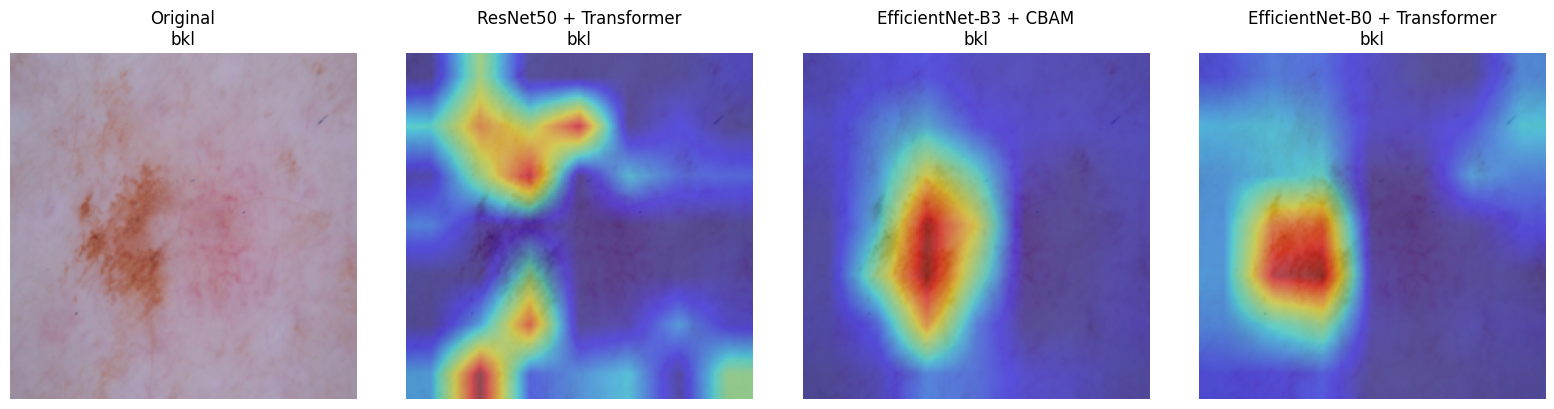

In [ ]:
# COMPARE GRAD-CAM
plt.figure(figsize=(16, 4))

# Original
plt.subplot(1, 4, 1)

plt.imshow(display_image)

plt.title(
    "Original\n"
    + class_names[true_label]
)

plt.axis("off")


# Model 1
plt.subplot(1, 4, 2)

plt.imshow(display_image)

plt.imshow(
    heatmap1,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "ResNet50 + Transformer\n"
    + class_names[prediction1]
)

plt.axis("off")


# Model 2
plt.subplot(1, 4, 3)

plt.imshow(display_image)

plt.imshow(
    heatmap2,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "EfficientNet-B3 + CBAM\n"
    + class_names[prediction2]
)

plt.axis("off")


# Model 3
plt.subplot(1, 4, 4)

plt.imshow(display_image)

plt.imshow(
    heatmap3,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "EfficientNet-B0 + Transformer\n"
    + class_names[prediction3]
)

plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# MC DROPOUT
def mc_dropout_prediction(
    model,
    image,
    passes=20
):

    # Enable dropout
    model.train()

    image = (
        image
        .unsqueeze(0)
        .to(device)
    )

    predictions = []

    with torch.no_grad():

        for _ in range(passes):

            output = model(
                image
            )

            probability = torch.softmax(
                output,
                dim=1
            )

            predictions.append(
                probability
                .cpu()
                .numpy()[0]
            )

    predictions = np.array(
        predictions
    )

    mean_probability = (
        predictions.mean(axis=0)
    )

    std_probability = (
        predictions.std(axis=0)
    )

    predicted_class = (
        mean_probability.argmax()
    )

    confidence = (
        mean_probability[
            predicted_class
        ]
    )

    uncertainty = (
        std_probability[
            predicted_class
        ]
    )

    return (
        predicted_class,
        confidence,
        uncertainty,
        mean_probability
    )

In [ ]:
# UNCERTAINTY FOR 3 MODELS
models = {
    "ResNet50 + Transformer": model1,
    "EfficientNet-B3 + CBAM": model2,
    "EfficientNet-B0 + Transformer": model3
}

uncertainty_results = []

for name, model in models.items():

    predicted_class, confidence, uncertainty, probabilities = (
        mc_dropout_prediction(
            model,
            image,
            passes=20
        )
    )

    uncertainty_results.append({

        "Model": name,

        "True Class":
            class_names[true_label],

        "Predicted Class":
            class_names[predicted_class],

        "Confidence":
            confidence,

        "Uncertainty":
            uncertainty
    })

uncertainty_df = pd.DataFrame(
    uncertainty_results
)

uncertainty_df

,Model,True Class,Predicted Class,Confidence,Uncertainty
0,ResNet50 + Transformer,bkl,nv,0.456145,0.029793
1,EfficientNet-B3 + CBAM,bkl,nv,0.350338,0.050554
2,EfficientNet-B0 + Transformer,bkl,nv,0.409345,0.037119


In [ ]:
# WRONG PREDICTIONS
wrong1 = np.where(
    y_true1 != y_pred1
)[0]

wrong2 = np.where(
    y_true2 != y_pred2
)[0]

wrong3 = np.where(
    y_true3 != y_pred3
)[0]

print(
    "Model 1 wrong:",
    len(wrong1)
)

print(
    "Model 2 wrong:",
    len(wrong2)
)

print(
    "Model 3 wrong:",
    len(wrong3)
)

Model 1 wrong: 220
Model 2 wrong: 240
Model 3 wrong: 214


In [ ]:
# PER-CLASS F1-COMPARISON
def per_class_f1(
    y_true,
    y_pred
):

    report = classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    return [
        report[class_name]["f1-score"]
        for class_name in class_names
    ]


f1_comparison = pd.DataFrame({

    "ResNet50 + Transformer":
        per_class_f1(
            y_true1,
            y_pred1
        ),

    "EfficientNet-B3 + CBAM":
        per_class_f1(
            y_true2,
            y_pred2
        ),

    "EfficientNet-B0 + Transformer":
        per_class_f1(
            y_true3,
            y_pred3
        )

}, index=class_names)

f1_comparison

,ResNet50 + Transformer,EfficientNet-B3 + CBAM,EfficientNet-B0 + Transformer
akiec,0.655172,0.770833,0.649123
bcc,0.822857,0.771930,0.807018
bkl,0.724719,0.704698,0.720497
df,0.666667,0.709677,0.764706
mel,0.674556,0.638498,0.664671
nv,0.928571,0.919171,0.931313
vasc,0.800000,0.777778,0.823529


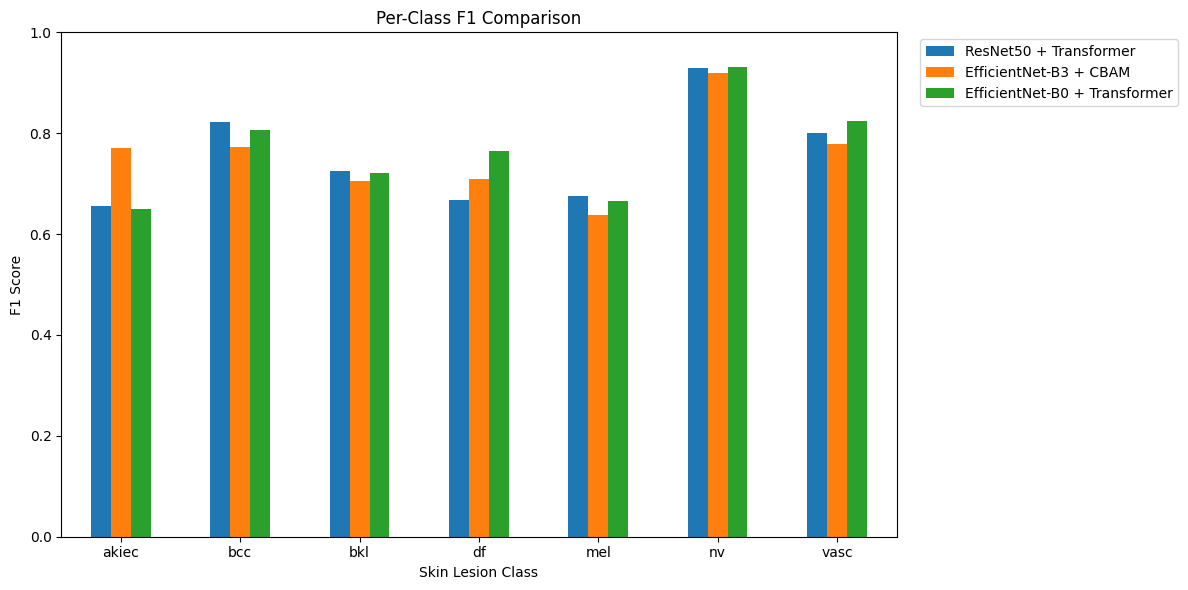

In [ ]:
# PER CLASS F1GRAPH
f1_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Per-Class F1 Comparison"
)

plt.xlabel(
    "Skin Lesion Class"
)

plt.ylabel(
    "F1 Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

plt.show()

In [ ]:
# AUTOMATICALLY IDENTIFY BEST MODEL
best_model_name = (
    results_df["Macro F1"]
    .idxmax()
)

best_f1 = (
    results_df.loc[
        best_model_name,
        "Macro F1"
    ]
)

best_accuracy = (
    results_df.loc[
        best_model_name,
        "Accuracy"
    ]
)

print(
    "Best model based on Macro-F1:"
)

print(
    best_model_name
)

print(
    "Macro-F1:",
    round(best_f1, 4)
)

print(
    "Accuracy:",
    round(best_accuracy, 4)
)

Best model based on Macro-F1:
EfficientNet-B0 + Transformer
Macro-F1: 0.7658
Accuracy: 0.8576


In [ ]:
# FINAL RESULTS TABLE
final_table = results_df.copy()

final_table["Training Time (min)"] = [
    time1 / 60,
    time2 / 60,
    time3 / 60
]

final_table["Parameters"] = [
    count_parameters(model1),
    count_parameters(model2),
    count_parameters(model3)
]

final_table = final_table.sort_values(
    "Macro F1",
    ascending=False
)

display(
    final_table.round(4)
)

,Accuracy,Macro Precision,Macro Recall,Macro F1,Balanced Accuracy,Training Time (min),Parameters
EfficientNet-B0 + Transformer,0.8576,0.7346,0.8078,0.7658,0.8078,23.0328,5392003
EfficientNet-B3 + CBAM,0.8403,0.7437,0.7923,0.7561,0.7923,26.5755,11002001
ResNet50 + Transformer,0.8536,0.7025,0.8201,0.7532,0.8201,26.9162,25089095
